## Exploratory Data Analysis Summary

### Dataset
- Training Samples: 691,369
- Testing Samples: 296,302
- Numerical Features: 9
- Categorical Features: 3
- Target: Binary Classification

### Data Quality
- No duplicate rows
- Unique IDs
- Missing values present in most features (4–19%)
- No invalid numerical values detected

### Target Distribution
- Class 0: 29.06%
- Class 1: 70.94%
- Moderate class imbalance

### Strong Predictors
- daily_screen_time_hours
- weekend_screen_time
- social_media_hours

### Weak Predictors
- age
- sleep_hours
- notifications_per_day

### Categorical Features
- Balanced distributions
- Limited individual predictive power
- Retained for interaction effects

### Correlation
- Highest target correlation:
  - daily_screen_time_hours (0.61)
  - weekend_screen_time (0.59)
  - social_media_hours (0.53)

### Preprocessing Strategy
- Median imputation for numerical features
- Mode imputation for categorical features
- One-Hot Encoding for linear models
- Native categorical handling (or encoding) for tree-based models
- Stratified Cross Validation

### Feature Engineering Candidates
- Entertainment Hours
- Weekend Difference
- Entertainment Ratio
- Study Ratio
- Notification Rate
- App Open Rate

In [1]:
# ==========================================================
# PHASE 02 | IMPORT LIBRARIES
# ==========================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==========================================================
# PHASE 02 | PROJECT PATHS
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_PATH = RAW_DATA_DIR / "train.csv"
TEST_PATH = RAW_DATA_DIR / "test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
# ==========================================================
# PHASE 02 | DUPLICATE ANALYSIS
# ==========================================================

train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print(f"Duplicate rows in Train : {train_duplicates:,}")
print(f"Duplicate rows in Test  : {test_duplicates:,}")

Duplicate rows in Train : 0
Duplicate rows in Test  : 0


In [4]:
# ==========================================================
# PHASE 02 | ID UNIQUENESS
# ==========================================================

print("Train ID Unique :", train_df["id"].is_unique)
print("Test ID Unique  :", test_df["id"].is_unique)

Train ID Unique : True
Test ID Unique  : True


In [5]:
# ==========================================================
# PHASE 02 | MISSING VALUE SUMMARY
# ==========================================================

missing_summary = (
    train_df.isnull()
            .sum()
            .to_frame(name="Missing_Count")
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"] / len(train_df) * 100
).round(2)

missing_summary = (
    missing_summary
    .sort_values("Missing_Percentage", ascending=False)
)

missing_summary

,Missing_Count,Missing_Percentage
social_media_hours,133995,19.38
gaming_hours,126821,18.34
weekend_screen_time,112063,16.21
daily_screen_time_hours,95854,13.86
app_opens_per_day,80710,11.67
notifications_per_day,67584,9.78
stress_level,55148,7.98
work_study_hours,51518,7.45
sleep_hours,44480,6.43
academic_work_impact,44224,6.40


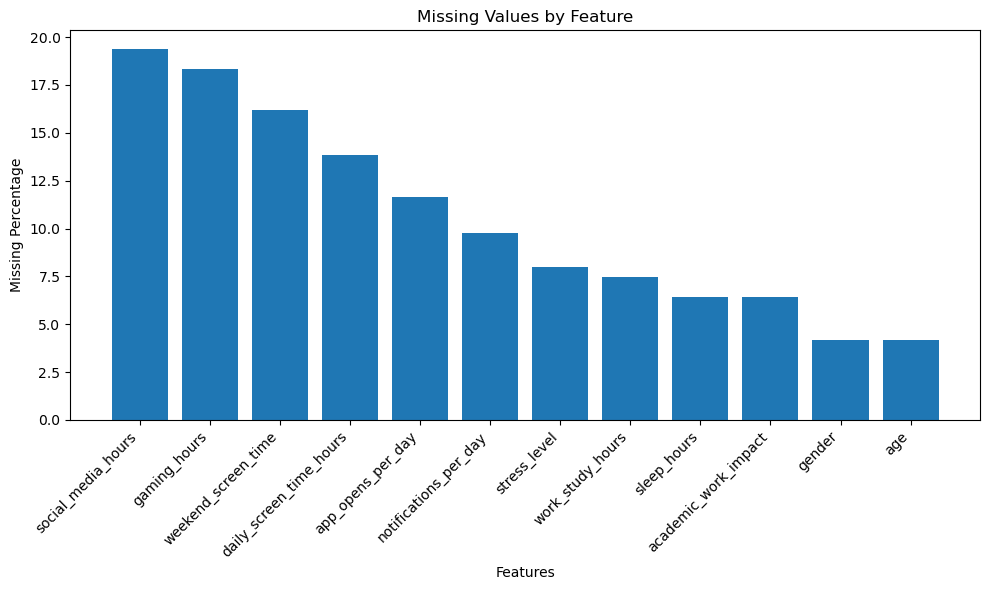

In [6]:
# ==========================================================
# PHASE 02 | MISSING VALUE VISUALIZATION
# ==========================================================

missing_features = missing_summary[
    missing_summary["Missing_Count"] > 0
]

plt.figure(figsize=(10, 6))

plt.bar(
    missing_features.index,
    missing_features["Missing_Percentage"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing Percentage")
plt.xlabel("Features")
plt.title("Missing Values by Feature")

plt.tight_layout()
plt.show()

In [7]:
# ==========================================================
# PHASE 02 | TARGET DISTRIBUTION
# ==========================================================

target_counts = train_df["addicted_label"].value_counts().sort_index()

print(target_counts)

addicted_label
0    200895
1    490474
Name: count, dtype: int64


In [8]:
# ==========================================================
# PHASE 02 | TARGET PERCENTAGE
# ==========================================================

target_percentage = (
    train_df["addicted_label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(target_percentage)

addicted_label
0    29.06
1    70.94
Name: proportion, dtype: float64


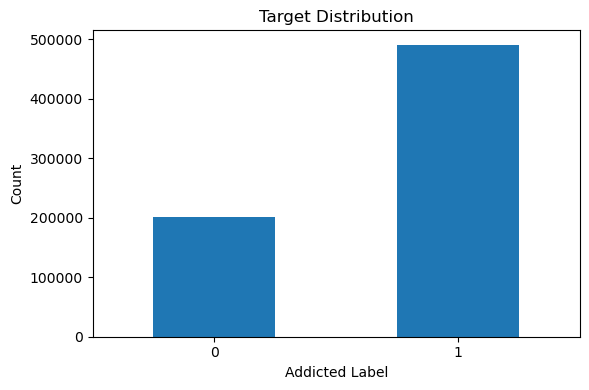

In [9]:
# ==========================================================
# PHASE 02 | TARGET VISUALIZATION
# ==========================================================

target_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Target Distribution")
plt.xlabel("Addicted Label")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [10]:
# ==========================================================
# PHASE 02 | NUMERICAL SUMMARY
# ==========================================================

numerical_columns = train_df.select_dtypes(include=["number"]).columns.drop("addicted_label")

numerical_summary = train_df[numerical_columns].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


In [11]:
# ==========================================================
# PHASE 02 | NUMERICAL FEATURE RANGES
# ==========================================================

range_summary = pd.DataFrame({
    "Minimum": train_df[numerical_columns].min(),
    "Maximum": train_df[numerical_columns].max()
})

range_summary

,Minimum,Maximum
id,0.00,691368.00
age,18.00,35.00
daily_screen_time_hours,0.50,15.00
social_media_hours,0.00,8.00
gaming_hours,0.00,4.00
work_study_hours,0.00,6.00
sleep_hours,4.50,9.00
notifications_per_day,20.00,250.00
app_opens_per_day,15.00,180.00
weekend_screen_time,0.51,17.56


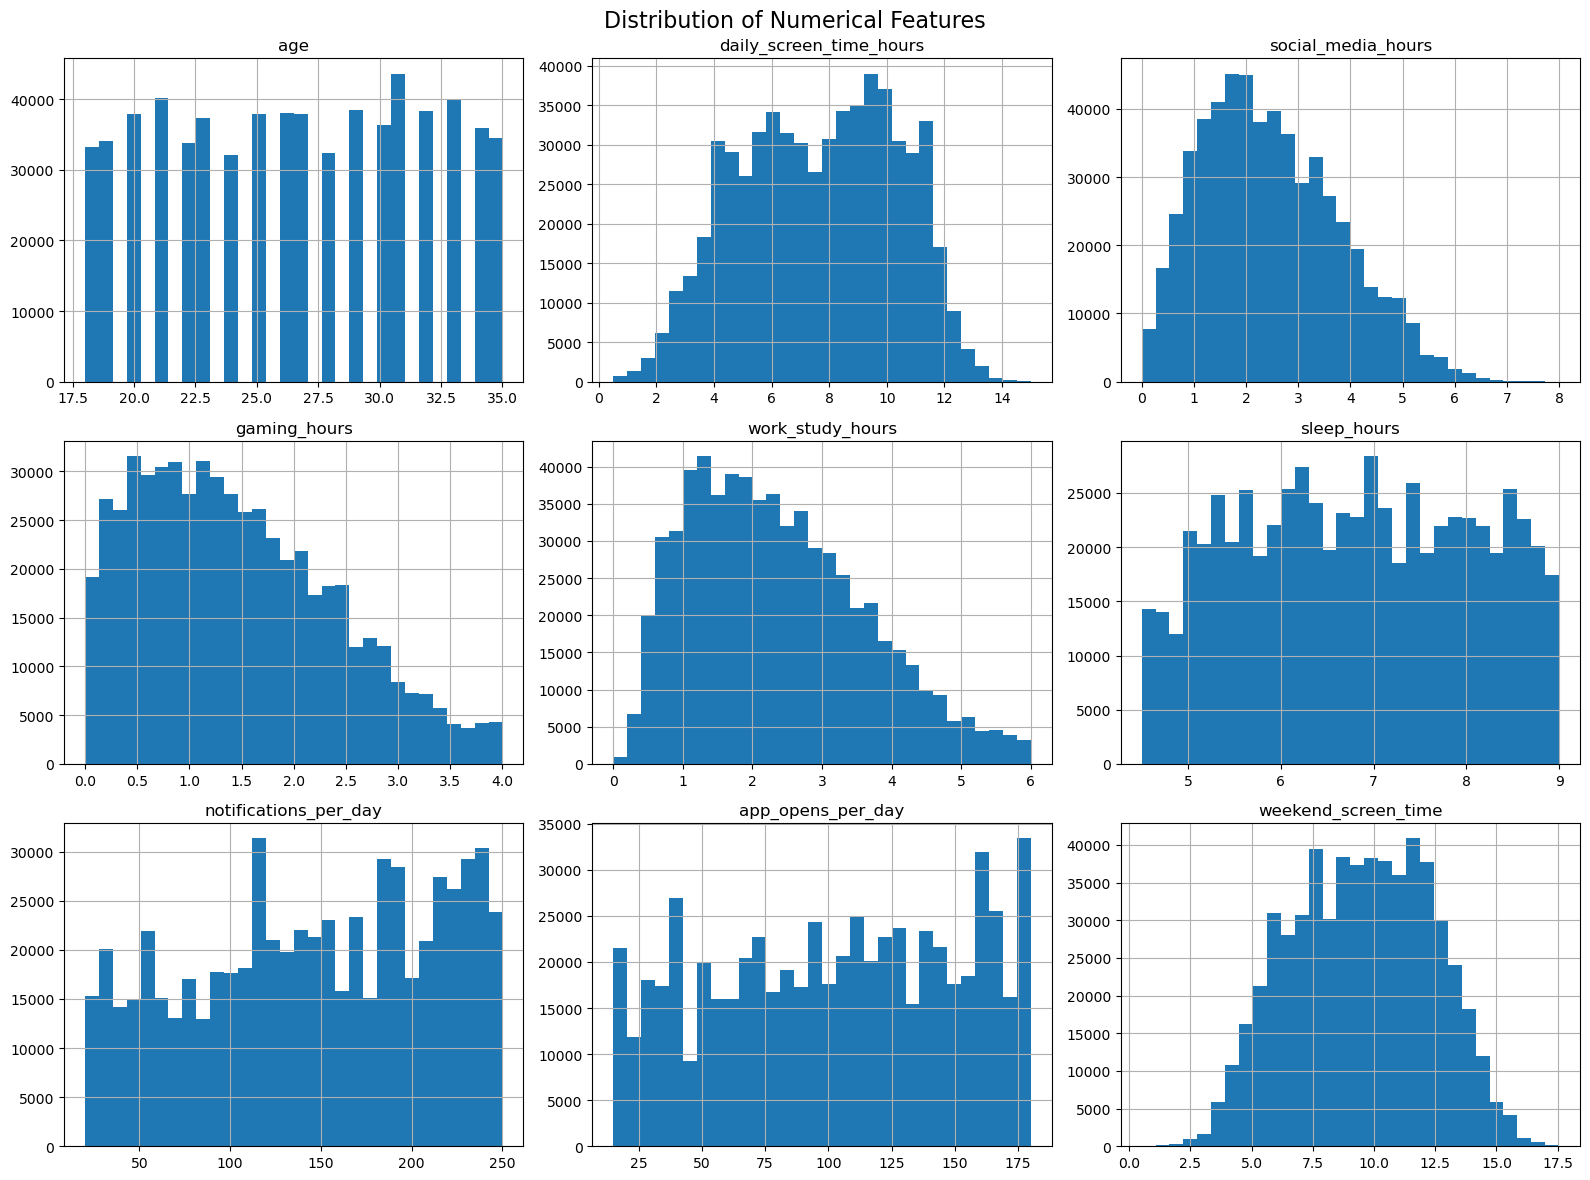

In [12]:
# ==========================================================
# PHASE 02 | NUMERICAL FEATURE DISTRIBUTIONS
# ==========================================================

numerical_columns = train_df.select_dtypes(include=["number"]).columns.drop(["id", "addicted_label"])

train_df[numerical_columns].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
# ==========================================================
# PHASE 02 | CATEGORICAL FEATURE SUMMARY
# ==========================================================

categorical_columns = train_df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("=" * 60)
    print(f"{column}")
    print("=" * 60)

    print(train_df[column].value_counts(dropna=False))

    print("\n")

gender
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64


stress_level
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64


academic_work_impact
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64




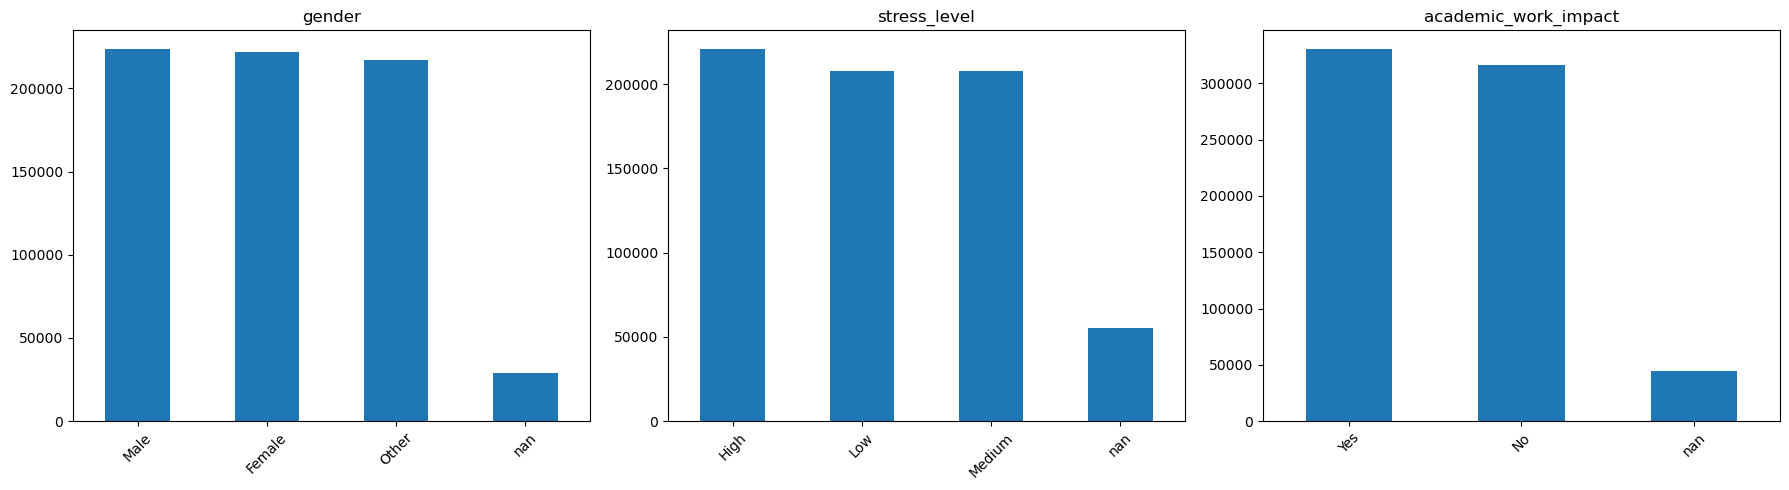

In [14]:
# ==========================================================
# PHASE 02 | CATEGORICAL DISTRIBUTIONS
# ==========================================================

fig, axes = plt.subplots(1, len(categorical_columns), figsize=(18, 5))

for ax, column in zip(axes, categorical_columns):
    train_df[column].value_counts(dropna=False).plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(column)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# ==========================================================
# PHASE 02 | FEATURE CATEGORIES
# ==========================================================

target_column = "addicted_label"

numerical_columns = train_df.select_dtypes(include=["number"]).columns.tolist()
numerical_columns.remove("id")
numerical_columns.remove(target_column)

categorical_columns = train_df.select_dtypes(include="object").columns.tolist()

print("Numerical Features:", numerical_columns)
print()
print("Categorical Features:", categorical_columns)

Numerical Features: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

Categorical Features: ['gender', 'stress_level', 'academic_work_impact']


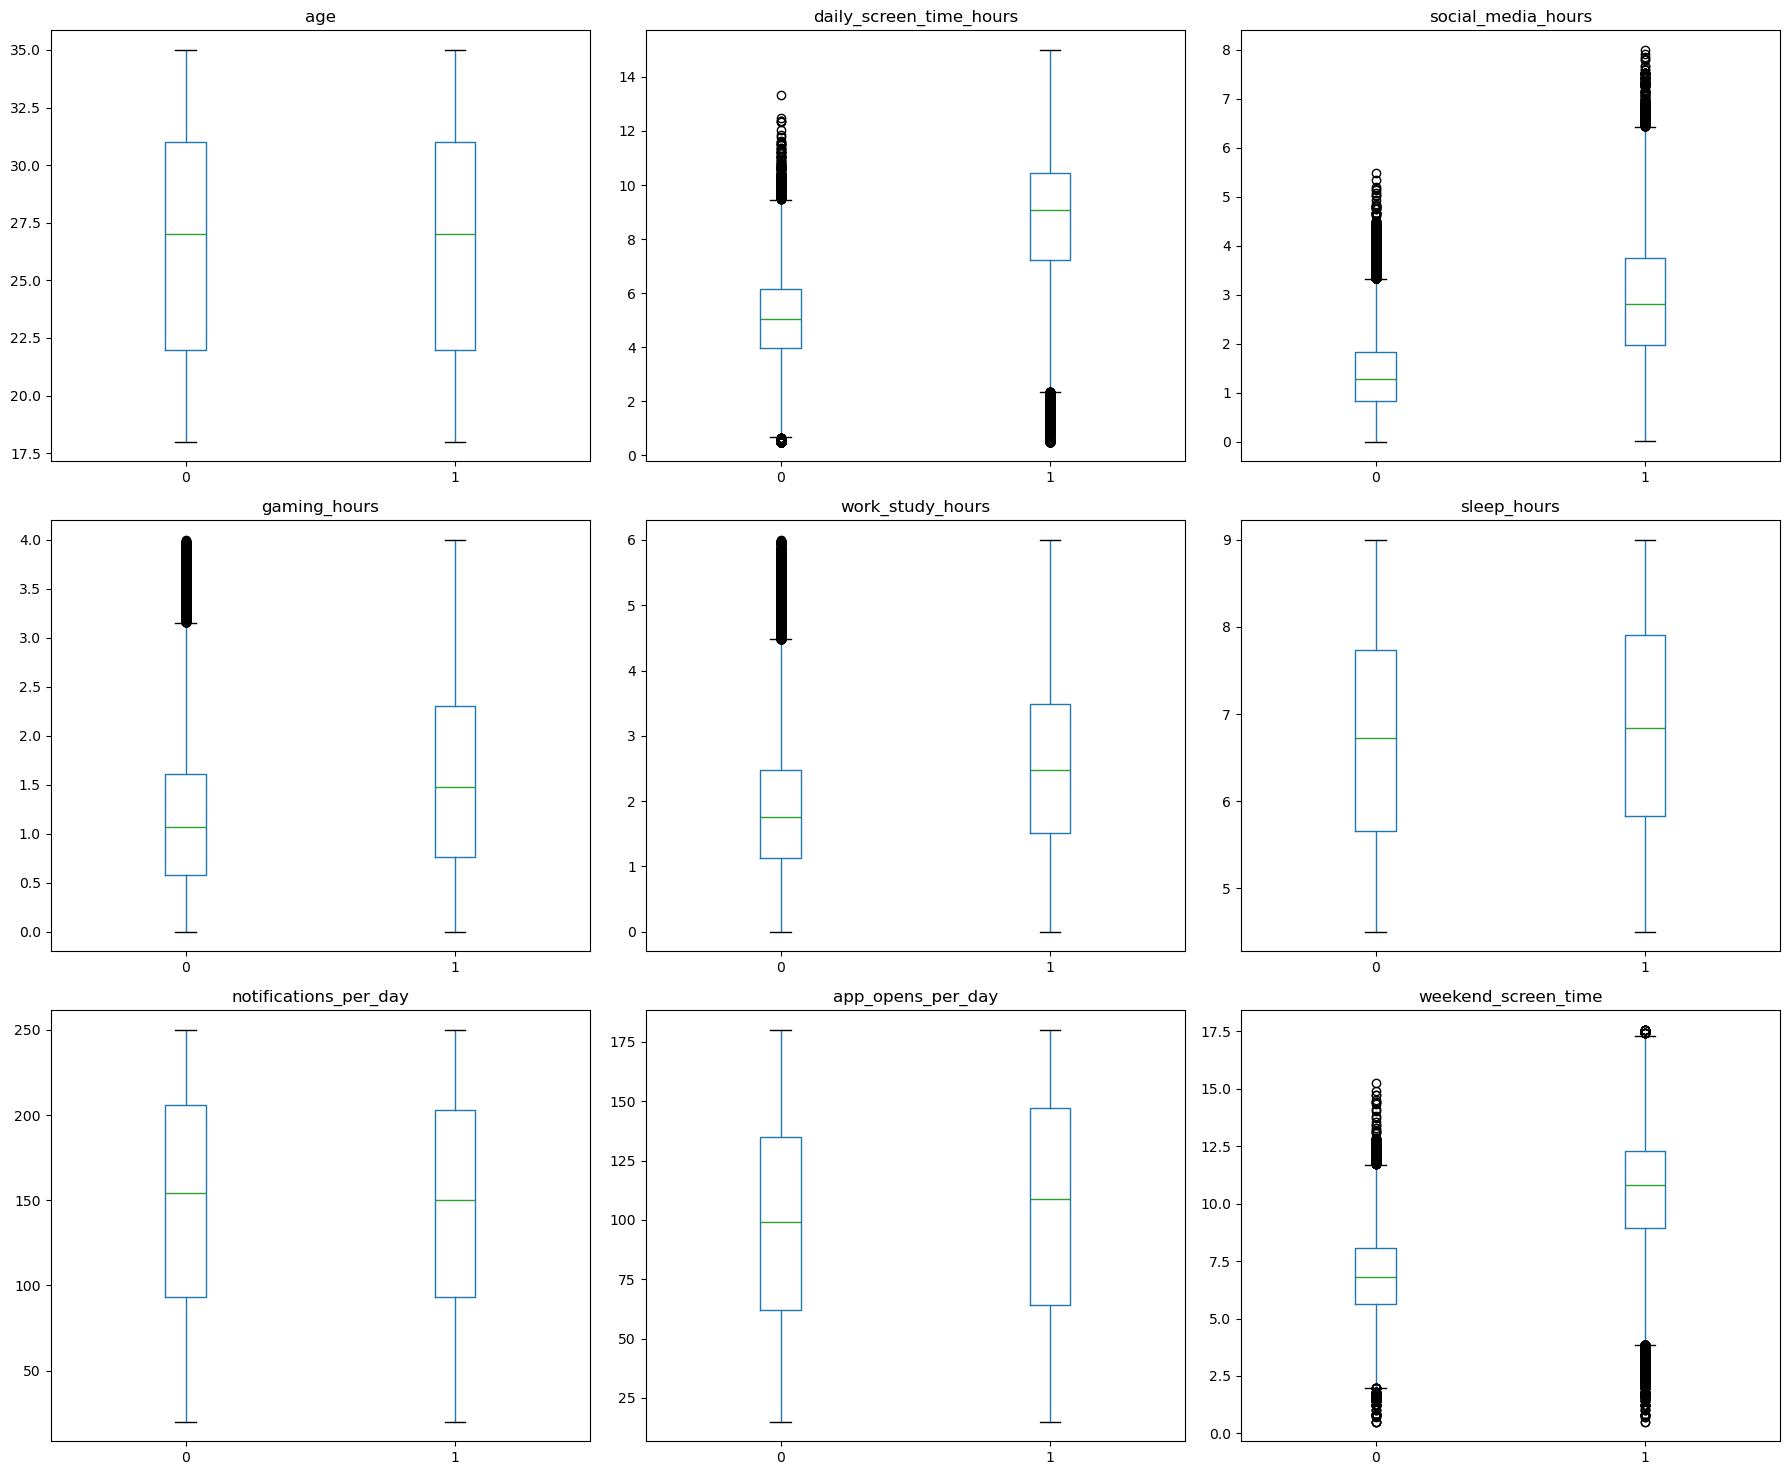

In [16]:
# ==========================================================
# PHASE 02 | NUMERICAL FEATURES VS TARGET
# ==========================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for ax, column in zip(axes, numerical_columns):

    train_df.boxplot(
        column=column,
        by=target_column,
        ax=ax,
        grid=False
    )

    ax.set_title(column)
    ax.set_xlabel("")

plt.suptitle("")
plt.tight_layout()

plt.show()

In [17]:
# ==========================================================
# PHASE 02 | CATEGORICAL FEATURES VS TARGET
# ==========================================================

for column in categorical_columns:
    print("=" * 60)
    print(column)
    print("=" * 60)

    target_distribution = (
        pd.crosstab(
            train_df[column],
            train_df[target_column],
            normalize="index"
        ) * 100
    ).round(2)

    display(target_distribution)

gender


addicted_label,0,1
gender,,
Female,29.62,70.38
Male,27.68,72.32
Other,29.90,70.10


stress_level


addicted_label,0,1
stress_level,,
High,28.86,71.14
Low,28.88,71.12
Medium,29.43,70.57


academic_work_impact


addicted_label,0,1
academic_work_impact,,
No,28.90,71.10
Yes,29.21,70.79


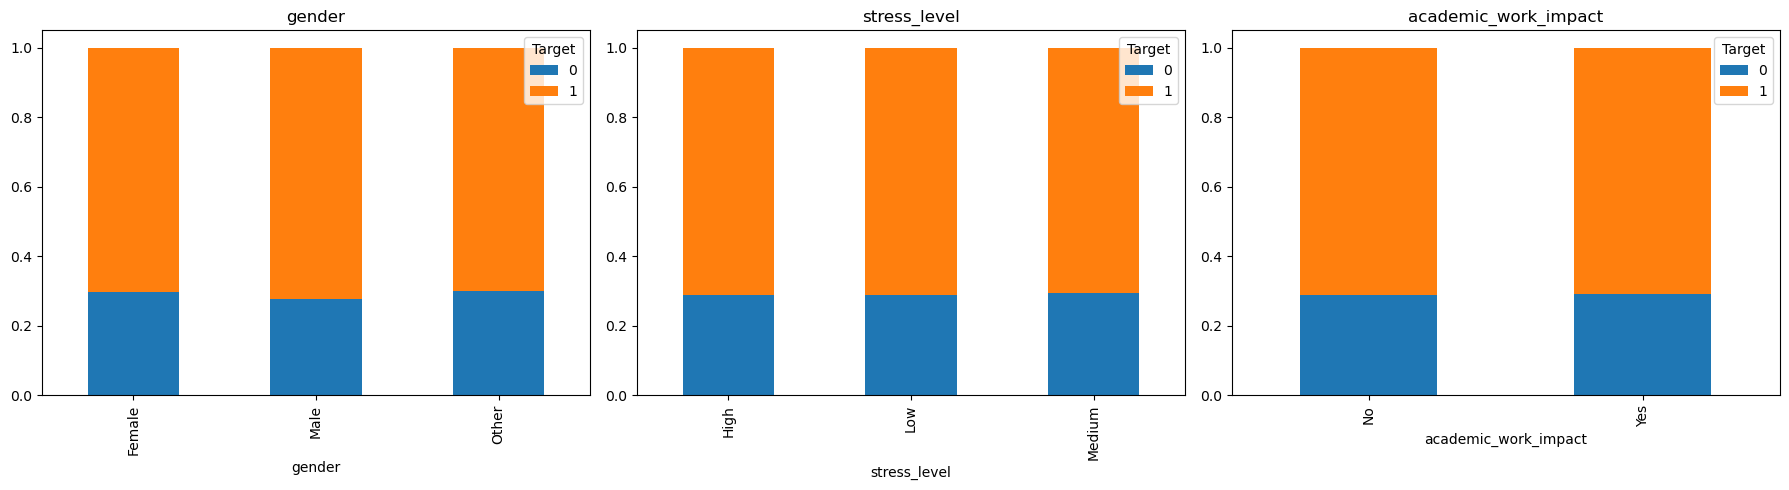

In [19]:
# ==========================================================
# PHASE 02 | CATEGORICAL FEATURE DISTRIBUTION BY TARGET
# ==========================================================

fig, axes = plt.subplots(1, len(categorical_columns), figsize=(18, 5))

for ax, column in zip(axes, categorical_columns):

    pd.crosstab(
        train_df[column],
        train_df[target_column],
        normalize="index"
    ).plot(
        kind="bar",
        stacked=True,
        ax=ax
    )

    ax.set_title(column)
    ax.legend(title="Target")

plt.tight_layout()
plt.show()

In [20]:
# ==========================================================
# PHASE 02 | CORRELATION MATRIX
# ==========================================================

correlation_matrix = train_df[numerical_columns + [target_column]].corr(numeric_only=True)

correlation_matrix.round(2)

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
age,1.00,0.01,0.01,0.00,0.00,0.00,-0.01,0.00,0.01,0.00
daily_screen_time_hours,0.01,1.00,0.60,0.43,0.53,0.03,0.00,0.05,0.80,0.61
social_media_hours,0.01,0.60,1.00,0.09,0.10,0.02,-0.01,0.05,0.48,0.53
gaming_hours,0.00,0.43,0.09,1.00,0.05,0.02,0.02,0.02,0.34,0.21
work_study_hours,0.00,0.53,0.10,0.05,1.00,-0.00,-0.01,0.01,0.42,0.25
sleep_hours,0.00,0.03,0.02,0.02,-0.00,1.00,0.03,0.02,0.03,0.04
notifications_per_day,-0.01,0.00,-0.01,0.02,-0.01,0.03,1.00,0.01,-0.00,-0.01
app_opens_per_day,0.00,0.05,0.05,0.02,0.01,0.02,0.01,1.00,0.05,0.06
weekend_screen_time,0.01,0.80,0.48,0.34,0.42,0.03,-0.00,0.05,1.00,0.59
addicted_label,0.00,0.61,0.53,0.21,0.25,0.04,-0.01,0.06,0.59,1.00


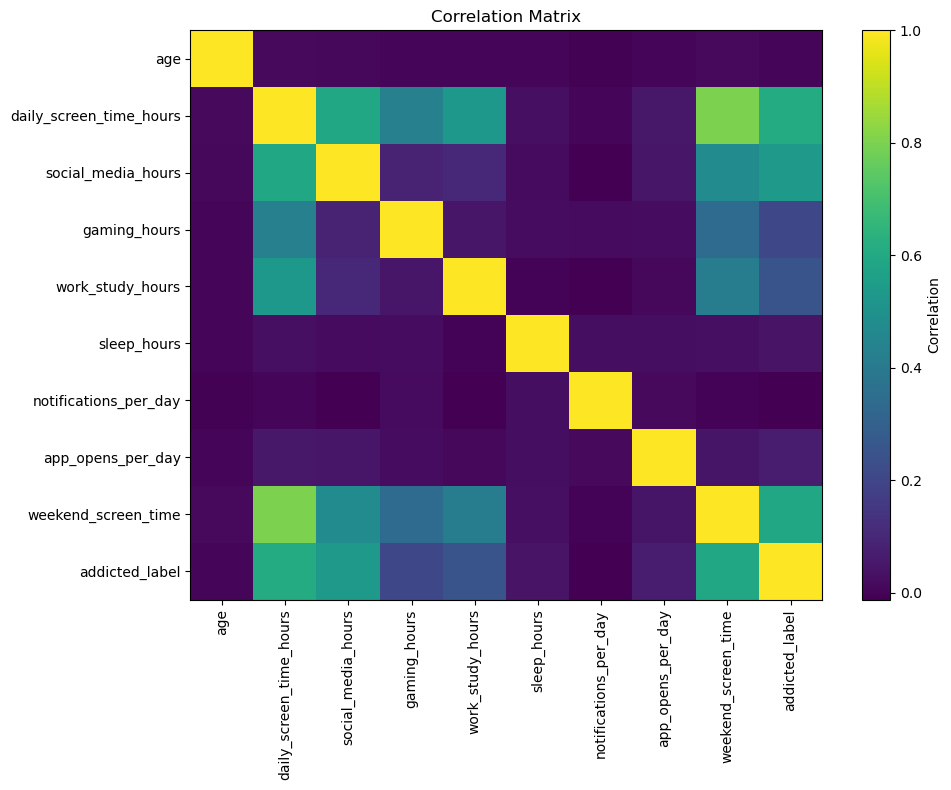

In [21]:
# ==========================================================
# PHASE 02 | CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()